In [1]:
import numpy as np
import sys
sys.path.append('./diting')
import gemini_models as models

/opt/zb/miniconda3/envs/dtbf_zb/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Please 'pip install apex'
Please 'pip install xformers'
Please 'pip install apex'
Please 'pip install xformers'


In [148]:
import obspy
import torch
import os
import json
import yaml
from diting.downstream.gemini_utils import get_args as get_args_diting
import gemini_util_light as util
import loader_light as loader
from torch.utils.data import DataLoader
import gemini_models as models
import matplotlib.pyplot as plt

In [3]:
config_path = './pga_configs/transformer_italy_plain_ensemble.json'
diting_config_path = './diting/config/conf_reg.yml'

In [4]:
config = json.load(open(config_path, 'r'))

In [5]:
diting_args, ds_init = get_args_diting()
with open(diting_args.conf_file, 'r') as f:
    diting_conf_data = yaml.safe_load(f)
vars(diting_args).update(diting_conf_data)

In [6]:
depth = 24
if depth % diting_args.num_interactions != 0:
    diting_args.num_interactions -= 1
n = (depth - 1)//diting_args.num_interactions
diting_args.interaction_indexes = [[i*n, (i+1)*n] for i in range(diting_args.num_interactions)]
if diting_args.num_interactions * n != depth:
    diting_args.interaction_indexes.append([diting_args.num_interactions*n, depth])

In [7]:
is_dist, rank, world_size, local_rank = util.setup_distributed()

In [8]:
device = 'cuda:0'

In [9]:
training_params = config['training_params']

In [10]:
generator_params = training_params.get('generator_params', [training_params.copy()])

In [11]:
key = generator_params[0].get('key', 'MA')
pos_offset = generator_params[0].get('pos_offset', (-21, -69))
pga_key = generator_params[0].get('pga_key', 'pga')
no_event_token = config['model_params'].get('no_event_token', False)


In [12]:
experiment_path = 'experiment'
suffix = ''
output_dir = os.path.join(experiment_path, f'evaluation{suffix}', 'test')
test_set = True
# if not os.path.isdir(os.path.join(experiment_path, f'evaluation{suffix}')):
#     os.mkdirs(os.path.join(experiment_path, f'evaluation{suffix}'))
if not os.path.isdir(output_dir):
    os.makedirs(output_dir, exist_ok=True)


In [13]:
if not isinstance(training_params['data_path'], list):
    training_params['data_path'] = [training_params['data_path']]
overwrite_sampling_rate = training_params.get('overwrite_sampling_rate', None)


In [20]:
limit = 300

In [21]:
full_data_train = [loader.load_events(data_path, event_metadata_path='train_ev.csv',limit=limit,
                                      parts=(True, False, False),
                                      shuffle_train_dev=generator.get('shuffle_train_dev', False),
                                      custom_split=generator.get('custom_split', None),
                                      min_mag=generator.get('min_mag', None),
                                      mag_key=generator.get('key', 'MA'),
                                      overwrite_sampling_rate=overwrite_sampling_rate,
                                      decimate_events=generator.get('decimate_events', None))
                   for data_path, generator in zip(training_params['data_path'], generator_params)]

In [23]:
full_data_dev = [loader.load_events(data_path, event_metadata_path='test_ev.csv',limit=limit,
                                    parts=(False, True, False),
                                    shuffle_train_dev=generator.get('shuffle_train_dev', False),
                                    custom_split=generator.get('custom_split', None),
                                    min_mag=generator.get('min_mag', None),
                                    mag_key=generator.get('key', 'MA'),
                                    overwrite_sampling_rate=overwrite_sampling_rate,
                                    decimate_events=generator.get('decimate_events', None))
                 for data_path, generator in zip(training_params['data_path'], generator_params)]


In [24]:
event_metadata_train = [d[0] for d in full_data_train]
metadata_train = [d[2] for d in full_data_train]
event_metadata_dev = [d[0] for d in full_data_dev]
metadata_dev = [d[2] for d in full_data_dev]

sampling_rate = metadata_train[0]['sampling_rate']


In [25]:
max_stations = config['model_params']['max_stations']

config['model_params']['n_datasets'] = len(metadata_train)

ensemble = config.get('ensemble', 1)

super_config = config.copy()
super_training_params = training_params.copy()
super_model_params = config['model_params'].copy()


In [28]:
ens_id = 0
# config = super_config.copy()
# config['ens_id'] = ens_id
# training_params = super_training_params.copy()
# training_params['weight_path'] = os.path.join(training_params['weight_path'], f'{ens_id}')
# config['training_params'] = training_params
# config['model_params'] = super_model_params.copy()

# if training_params.get('ensemble_rotation', False):
#     # Rotated by angles between 0 and pi/4
#     config['model_params']['rotation'] = np.pi / 4 * ens_id / (ensemble - 1)


In [29]:
single_station_model, full_model = models.build_transformer_model(**config['model_params'],
#                                                                          trace_length=data_train[0]['waveforms'][0].shape[1],
                                                                  trace_length=10000,
                                                                  diting_args=diting_args
)

[linear_probe/none]Trainable parameters: 5682863
[linear_probe/none]Trainable parameters: 6272687
Sequential(
  (0): ViTAdapter(
    (backbone): PatchTSTEncoder(
      (W_p): Conv1d(3, 512, kernel_size=(50,), stride=(50,))
      (dropout): Dropout(p=0.0, inplace=False)
      (encoder): TSTEncoder(
        (layers): ModuleList(
          (0-23): 24 x TSTEncoderLayer(
            (self_attn): MultiheadAttention_ROPE(
              (q_proj): Linear(in_features=512, out_features=512, bias=True)
              (k_proj): Linear(in_features=512, out_features=512, bias=True)
              (v_proj): Linear(in_features=512, out_features=512, bias=True)
              (o_proj): Linear(in_features=512, out_features=512, bias=True)
              (rotary_emb): LlamaRotaryEmbedding()
              (sdp_attn): ScaledDotProductAttention(
                (attn_dropout): Dropout(p=0.0, inplace=False)
              )
            )
            (drop_path1): Identity()
            (norm_attn): LlamaRMSNorm()


In [34]:
ckpt_path = 'weights_transformer_italy_plain_ensemble/full_model_191.pth'

In [35]:
state_dict = torch.load(ckpt_path, map_location='cpu')

In [36]:
state_dict.keys()

dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'loss'])

In [37]:
full_model.load_state_dict(state_dict['model_state_dict'])

<All keys matched successfully>

In [75]:
full_model.to(device)

FullModel(
  (waveform_model): Sequential(
    (0): ViTAdapter(
      (backbone): PatchTSTEncoder(
        (W_p): Conv1d(3, 512, kernel_size=(50,), stride=(50,))
        (dropout): Dropout(p=0.0, inplace=False)
        (encoder): TSTEncoder(
          (layers): ModuleList(
            (0-23): 24 x TSTEncoderLayer(
              (self_attn): MultiheadAttention_ROPE(
                (q_proj): Linear(in_features=512, out_features=512, bias=True)
                (k_proj): Linear(in_features=512, out_features=512, bias=True)
                (v_proj): Linear(in_features=512, out_features=512, bias=True)
                (o_proj): Linear(in_features=512, out_features=512, bias=True)
                (rotary_emb): LlamaRotaryEmbedding()
                (sdp_attn): ScaledDotProductAttention(
                  (attn_dropout): Dropout(p=0.0, inplace=False)
                )
              )
              (drop_path1): Identity()
              (norm_attn): LlamaRMSNorm()
              (gate_proj): Li

In [45]:
times = [0.5, 1, 2, 4, 8, 16, 25]
alphas = [0.3, 0.4, 0.5, 0.6, 0.7]

In [60]:
i = 0
generator_param_set = generator_params[i]
# sampling_rate
noise_seconds = generator_param_set.get('noise_seconds', 5)
cutout = ( sampling_rate * (noise_seconds + generator_param_set['cutout_start']),
           sampling_rate * (noise_seconds + generator_param_set['cutout_end']) )  
n_pga_targets = config['model_params'].get('n_pga_targets', 0)
train_generators = [util.PreloadedEventGenerator(event_metadata=event_metadata_train[i],
                                                  metadata=metadata_train[i],
                                                  data_path=training_params['data_path'][i],
                                                  generator_params=generator_params[i],
                                                  coords_target=True,
                                                  label_smoothing=True,
                                                  station_blinding=True,
                                                  cutout=cutout,
                                                  pga_targets=n_pga_targets,
                                                  max_stations=max_stations,
                                                  sampling_rate=sampling_rate,
                                                  no_event_token=no_event_token,
                                                  **generator_param_set)]

old_oversample = generator_param_set.get('oversample', 1)
generator_param_set['oversample'] = 4
validation_generators = [util.PreloadedEventGenerator(event_metadata=event_metadata_dev[i],
                                                       metadata=metadata_dev[i],
                                                       data_path=training_params['data_path'][i],
                                                       generator_params=generator_params[i],
                                                       coords_target=True,
                                                       station_blinding=True,
                                                       cutout=cutout,
                                                       pga_targets=n_pga_targets,
                                                       max_stations=max_stations,
                                                       sampling_rate=sampling_rate,
                                                       no_event_token=no_event_token,
                                                       **generator_param_set)]
generator_param_set['oversample'] = old_oversample

if len(train_generators) == 0:
    train_dataset = train_generators[0]
    val_dataset = validation_generators[0]
else:
    dataset_bias = config['model_params'].get('dataset_bias', False)
    train_dataset = util.JointGenerator(train_generators, shuffle=True, dataset_id=dataset_bias)
    val_dataset = util.JointGenerator(validation_generators, shuffle=True, dataset_id=dataset_bias)


Unused parameters: batch_size, translate, shuffle_train_dev, custom_split, cutout_start, cutout_end
Unused parameters: batch_size, translate, shuffle_train_dev, custom_split, cutout_start, cutout_end


In [63]:
train_loader = DataLoader(train_dataset, batch_size=generator_params[0]['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=generator_params[0]['batch_size'], shuffle=True)

In [70]:
for inputs, labels in train_loader:
    if isinstance(inputs, list):
        inputs, labels = [i.to(device) for i in inputs], [l.to(device) for l in labels]
    else:
        inputs, labels = inputs.to(device), labels.to(device)
    break

In [76]:
with torch.no_grad():
    if isinstance(inputs, list):
        outputs = full_model(*inputs)
    else:
        outputs = full_model(inputs)


In [199]:
def mixture_density_loss_full(y_pred, y_true, eps=1e-6, d=1, mean=True, print_shapes=False):
    res_comps = ['mag', 'loc', 'pga']
    res_weight = np.array([1.,1.,1.])
    res_weight = res_weight / np.sum(res_weight)
    loss = 0.
    for i, res_comp in enumerate(res_comps):
        alpha = y_pred[i][..., 0]
        log_density = torch.zeros_like(y_pred[i][..., 0]).to(y_pred[i].device)  # Move to device
            
        if res_comp == 'loc':
            d = 3 
        else:
            d = 1 

        for j in range(d):
            mu = y_pred[i][..., j + 1]
            sigma = y_pred[i][..., j + 1 + d]
            sigma = torch.maximum(sigma, torch.tensor(eps).to(y_pred[i].device)) #Move to device
                
            y_true_tmp = y_true[i][..., j].clone()
            while y_true_tmp.dim() < sigma.dim():
                y_true_tmp = y_true_tmp.unsqueeze(-1)
            log_density +=  - torch.log(np.sqrt(2 * np.pi) * sigma) - (y_true_tmp - mu) ** 2 / (2 * sigma ** 2)
                
        log_density += torch.log(alpha)
        log_density = torch.logsumexp(log_density, dim=-1)
        loss -= res_weight[i]*torch.mean(log_density)
    return loss

In [200]:
mixture_density_loss_full(outputs, labels)

tensor(97.8525, device='cuda:0')

In [179]:
labels[0].shape

torch.Size([32, 1])

In [178]:
labels[2].shape

torch.Size([32, 15, 1, 1])

In [175]:
labels[2].shape

torch.Size([32, 15, 1, 1])

In [95]:
mean_mag = torch.sum(outputs[0][:,:,0]*outputs[0][:,:,1], axis=1)

In [124]:
mean_loc = torch.sum(outputs[1][:,:,0:1] * outputs[1][:,:,1::2], axis=1)

In [131]:
mean_pga = torch.sum(outputs[2][:,:,:,0]*outputs[2][:,:,:,1], axis=2)

In [152]:
ibatch = 0
istation = 0
st = obspy.Stream()
st += obspy.Trace(data=inputs[0][ibatch,istation,0].cpu().numpy(), header={'channel':'BHE'})
st += obspy.Trace(data=inputs[0][ibatch,istation,1].cpu().numpy(), header={'channel':'BHN'})
st += obspy.Trace(data=inputs[0][ibatch,istation,2].cpu().numpy(), header={'channel':'BHZ'})

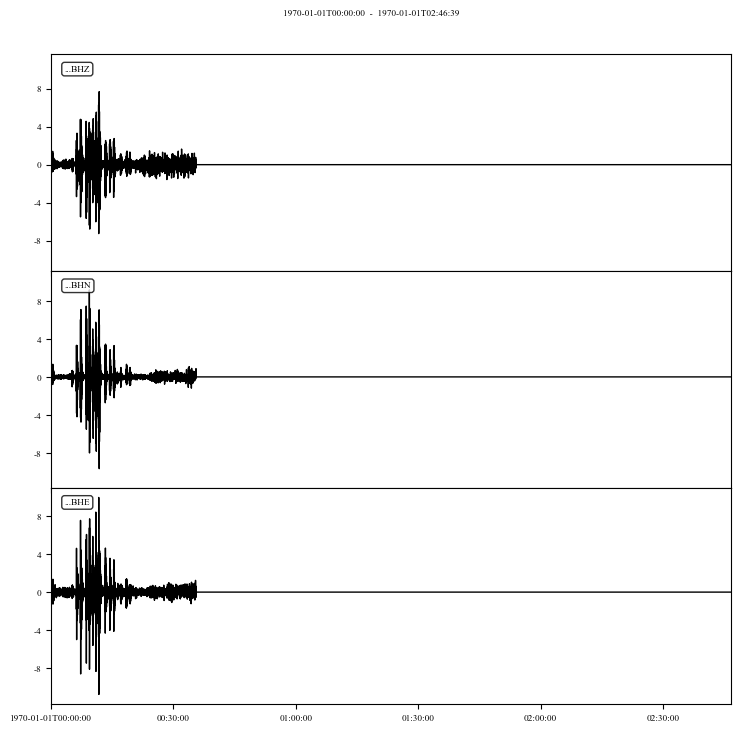

In [153]:
st.plot()
plt.show()
plt.close()

In [121]:
labels[1]

tensor([[[ 4.7839e+01],
         [ 9.7184e-01],
         [ 5.6000e-02]],

        [[ 4.6705e+01],
         [ 1.0319e+00],
         [ 7.1000e-02]],

        [[ 4.7228e+01],
         [ 1.5045e+00],
         [ 1.1100e-01]],

        [[ 4.8996e+01],
         [-8.3063e-01],
         [ 3.8000e-02]],

        [[ 4.8359e+01],
         [ 7.6947e-01],
         [ 3.6700e-01]],

        [[ 5.1924e+01],
         [-2.7443e+00],
         [ 2.0000e-02]],

        [[ 4.9531e+01],
         [-1.8403e+00],
         [ 2.2900e-01]],

        [[ 4.8848e+01],
         [-2.0304e+00],
         [ 3.1000e-02]],

        [[ 4.5115e+01],
         [ 3.4015e+00],
         [ 3.3000e+00]],

        [[ 4.9531e+01],
         [-1.8403e+00],
         [ 2.2900e-01]],

        [[ 4.6785e+01],
         [ 3.7795e+00],
         [ 1.1000e-02]],

        [[ 4.8996e+01],
         [-8.3063e-01],
         [ 3.8000e-02]],

        [[ 4.9577e+01],
         [-1.8514e+00],
         [ 2.3600e-01]],

        [[ 4.8492e+01],
         [ 1.4

In [115]:
models.mixture_density_loss(outputs, labels)

tensor(0.8394, device='cuda:0')

In [113]:
inputs[0][0].shape

torch.Size([25, 3, 10000])

In [112]:
inputs[0][1]

tensor([[[-0.5065,  1.0880, -0.1971,  ...,  0.0000,  0.0000,  0.0000],
         [ 1.5559, -0.6159, -0.3478,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.2672,  2.1579,  1.9894,  ...,  0.0000,  0.0000,  0.0000]],

        [[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],

        [[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],

        ...,

        [[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],

        [[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.

In [107]:
labels[0]

tensor([[3.1000],
        [2.7000],
        [2.9000],
        [4.4830],
        [3.4000],
        [3.7000],
        [4.8470],
        [3.2000],
        [3.9000],
        [4.9645],
        [3.2000],
        [4.4807],
        [2.7000],
        [3.1000],
        [3.1000],
        [3.2000],
        [3.2000],
        [3.0000],
        [3.9000],
        [3.8000],
        [3.0000],
        [3.0000],
        [3.2000],
        [2.8000],
        [3.6000],
        [2.9000],
        [4.4103],
        [3.1000],
        [3.4000],
        [2.7000],
        [4.1037],
        [2.7000]], device='cuda:0')